# 🏗️ Notebook 3 — Model Building

**Mục tiêu notebook:**
- **Bước 5:** Feature Engineering (11 derived features = 5 cũ + 6 mới)
- **Bước 6:** Feature Selection (correlation filter, Mutual Information)
- **Bước 7:** Preprocessing Pipeline → Split + Scale
- **Bước 8:** Chọn mô hình (LR / XGBoost / LightGBM)
- **Bước 9:** Huấn luyện 3 Models
- **Bước 10:** Đánh giá baseline
- **Bước 11:** Feature Reduction + Threshold Optimization

---

## 🗺️ Lộ trình 15 bước — Pipeline ML đầy đủ

| # | Bước | Notebook |
|:-:|------|----------|
| 1 | Đặt vấn đề | NB1 |
| 2 | Thu thập dữ liệu | NB1 |
| 3 | Tiền xử lý & EDA | NB2 |
| 4 | Định nghĩa Target | NB2 |
| **5** | **Feature Engineering** | **📌 NB3** |
| **6** | **Feature Selection** | **📌 NB3** |
| **7** | **Train/Test Split + Scale** | **📌 NB3** |
| **8** | **Chọn mô hình** | **📌 NB3** |
| **9** | **Huấn luyện** | **📌 NB3** |
| **10** | **Đánh giá baseline** | **📌 NB3** |
| **11** | **Feature Reduction** | **📌 NB3** |
| 12 | So sánh & Phân tích sâu | NB4 |
| 13 | Kết luận Model tốt nhất | NB4 |
| 14 | Threshold Optimization | NB4 |
| 15 | KPI Check | NB4 |

> 💡 **Notebook này bao phủ: Bước 5 → 11 / 15**

In [1]:
# ============================================================
# SECTION 0: Import thư viện
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

# Sklearn
from sklearn.model_selection   import train_test_split, cross_val_score
from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.impute             import SimpleImputer
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics           import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, average_precision_score,
    roc_curve, precision_recall_curve
)

# LightGBM
from lightgbm import LGBMClassifier
import lightgbm as lgb

# --- Thiết lập ---
RANDOM_STATE = 42
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

# --- Đường dẫn ---
BASE_DIR   = Path('.').resolve()
DATA_DIR   = BASE_DIR / 'data'
MODELS_DIR = BASE_DIR / 'models'
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Dataset mới — đã loại purchase_count (anti-leakage)
DATA_NEW = Path(r'C:\Users\ADMIN\MOCK PROJECT VTI\pred_repurchase_dataset.csv')

print('✅ Libraries loaded (LR | RandomForest | LightGBM)')
print(f'   BASE_DIR   : {BASE_DIR}')
print(f'   DATA_DIR   : {DATA_DIR}')
print(f'   MODELS_DIR : {MODELS_DIR}')
print(f'   DATA_NEW   : {DATA_NEW}')
print(f'   Exists?    : {DATA_NEW.exists()}')


✅ Libraries loaded (LR | RandomForest | LightGBM)
   BASE_DIR   : C:\Users\ADMIN\MOCK PROJECT VTI\mini_project_ml
   DATA_DIR   : C:\Users\ADMIN\MOCK PROJECT VTI\mini_project_ml\data
   MODELS_DIR : C:\Users\ADMIN\MOCK PROJECT VTI\mini_project_ml\models
   DATA_NEW   : C:\Users\ADMIN\MOCK PROJECT VTI\pred_repurchase_dataset.csv
   Exists?    : True


In [2]:
# ============================================================
# Load pred_repurchase_dataset.csv
# purchase_count đã bị XÓA khỏi file này → không cần loại thêm
# ============================================================
df = pd.read_csv(DATA_NEW, encoding='utf-8-sig')
print(f'✅ Loaded: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'   Source: pred_repurchase_dataset.csv')
print(f'   Columns: {list(df.columns)}')
print()
print('   Target distribution:')
vc = df['repurchase'].value_counts().sort_index()
for k, v in vc.items():
    label = 'tái mua' if k == 1 else 'không tái mua'
    print(f'   label={k} ({label:>14}): {v:>7,}  ({v/len(df)*100:.1f}%)')
print()
print('   ✅ purchase_count KHÔNG có trong dataset → không rò rỉ nhãn vào features')


✅ Loaded: 61,728 dòng × 20 cột
   Source: pred_repurchase_dataset.csv
   Columns: ['user_id', 'product_category', 'age', 'dominant_gender', 'dominant_location', 'total_view', 'total_click', 'total_cart', 'total_wishlist', 'total_interactions', 'click_through_rate', 'cart_rate', 'unique_brands', 'avg_price', 'avg_discount', 'avg_purchase_value', 'avg_rating', 'user_total_categories', 'category_share', 'repurchase']

   Target distribution:
   label=0 ( không tái mua):  41,507  (67.2%)
   label=1 (       tái mua):  20,221  (32.8%)

   ✅ purchase_count KHÔNG có trong dataset → không rò rỉ nhãn vào features



---
## 📌 Bước 5 / 15 — Feature Engineering (15 Derived Features)

> **Quy trình:** Định nghĩa features gốc (BƯỚC 1A) → Xử lý missing values (BƯỚC 1B) → Tạo 15 derived features (BƯỚC 2)  
> Toàn bộ thực hiện trên full dataset trước khi split (Anti-Leakage: split xảy ra ở Bước 7).



In [3]:
# ============================================================
# BƯỚC 1A: Định nghĩa features
#
# ⚠️  DATA LEAKAGE ĐÃ PHÁT HIỆN & SỬA:
#   total_interactions = view + click + cart + wishlist + purchase_count
#   Nhãn repurchase = 1 nếu purchase_count >= 5 (Otsu T*=4.02)
#   → residual = total_interactions - (view+click+cart+wishlist) = purchase_count CHÍNH XÁC
#   → Chỉ cần 1 rule "residual >= 5" → dự đoán đúng 100% toàn bộ dữ liệu
#   → total_interactions PHẢI BỊ XÓA khỏi features
#
# ⚠️  LOẠI dominant_gender & dominant_location:
#   Chi-Square test (NB2): p > 0.05 với n=61,728 → bằng chứng mạnh KHÔNG liên quan target
#   Cramér's V ≈ 0 → effect size gần như bằng 0
#   → Drop để tránh noise, giảm complexity, đảm bảo tính nhất quán
#
# ⚠️  LOẠI avg_price:
#   Đơn giá trung bình không phản ánh hành vi mua — thay vào đó avg_purchase_value
#   đã nắm bắt giá trị thực sự chi tiêu sau discount.
#   Derived features phụ thuộc avg_price (discount_sensitivity, price_to_value_ratio)
#   cũng bị loại để đảm bảo nhất quán.
# ============================================================
ID_COLS    = ['user_id', 'product_category']
TARGET_COL = 'repurchase'

DEMO_COLS       = ['age']   # dominant_gender, dominant_location đã loại (Chi-Square + Cramér's V ≈ 0)
BEHAVIORAL_COLS = ['total_view', 'total_click', 'total_cart', 'total_wishlist',
                   'click_through_rate', 'cart_rate']
# total_interactions ĐÃ BỊ XÓA — nó chứa purchase_count → data leakage nghiêm trọng

AGGREGATE_COLS  = ['unique_brands', 'avg_discount', 'avg_purchase_value',
                   'avg_rating', 'user_total_categories', 'category_share']
# avg_price đã loại — avg_purchase_value đủ đại diện cho giá trị mua thực
CATEGORICAL_COLS = []   # không còn categorical features cần encode

ALL_FEATURE_COLS = DEMO_COLS + BEHAVIORAL_COLS + AGGREGATE_COLS  # 13 raw features

X_raw = df[ALL_FEATURE_COLS].copy()
y     = df[TARGET_COL].astype(int)

print('✅ Feature selection — leakage đã được sửa, demographic noise đã loại')
print(f'   Demographic  ({len(DEMO_COLS)}): {DEMO_COLS}')
print(f'   Behavioral   ({len(BEHAVIORAL_COLS)}): {BEHAVIORAL_COLS}')
print(f'   Aggregates   ({len(AGGREGATE_COLS)}): {AGGREGATE_COLS}')
print(f'   Tổng raw features: {len(ALL_FEATURE_COLS)}  (đã bỏ dominant_gender, dominant_location, avg_price)')
print()
print(f'   Target (y): {y.value_counts().sort_index().to_dict()}')
print(f'   avg_rating NaN: {X_raw["avg_rating"].isna().sum():,} ({X_raw["avg_rating"].isna().mean()*100:.1f}%)')

✅ Feature selection — leakage đã được sửa, demographic noise đã loại
   Demographic  (1): ['age']
   Behavioral   (6): ['total_view', 'total_click', 'total_cart', 'total_wishlist', 'click_through_rate', 'cart_rate']
   Aggregates   (6): ['unique_brands', 'avg_discount', 'avg_purchase_value', 'avg_rating', 'user_total_categories', 'category_share']
   Tổng raw features: 13  (đã bỏ dominant_gender, dominant_location, avg_price)

   Target (y): {0: 41507, 1: 20221}
   avg_rating NaN: 17,306 (28.0%)


In [4]:
# ============================================================
# BƯỚC 1B: Impute avg_rating
# dominant_gender, dominant_location đã loại ở BƯỚC 1A
# → không còn LabelEncode, không cần phân tích demographic signal
# ============================================================
X_processed  = X_raw.copy()
le_encoders  = {}   # dict rỗng — giữ để preprocessor_obj tương thích

# avg_rating: ~28% NaN → impute bằng median trước split (global median)
# NOTE: Sẽ impute lại đúng chuẩn (train-only median) sau khi split
rating_median_global = X_processed['avg_rating'].median()
X_processed['avg_rating'] = X_processed['avg_rating'].fillna(rating_median_global)
print(f'   avg_rating: impute NaN bằng median = {rating_median_global:.4f}')
print(f'   Global impute dùng tạm — sau split sẽ dùng train-only median cho scaler')

print(f'\n✅ X_processed: {X_processed.shape}  (0 NaN: {X_processed.isna().sum().sum() == 0})')
print(f'   Features: {list(X_processed.columns)}')

# ── Lưu processed_data.csv — 14 raw features (imputed) + target ─────────────
processed_out = X_processed.copy()
processed_out['repurchase'] = y.values
processed_out.to_csv(DATA_DIR / 'processed_data.csv', index=False, encoding='utf-8-sig')
print(f'\n✅ processed_data.csv luu: {processed_out.shape}')
print(f'   → data/processed_data.csv  ({len(X_processed.columns)} features + target, sau impute)')


   avg_rating: impute NaN bằng median = 4.0000
   Global impute dùng tạm — sau split sẽ dùng train-only median cho scaler

✅ X_processed: (61728, 13)  (0 NaN: True)
   Features: ['age', 'total_view', 'total_click', 'total_cart', 'total_wishlist', 'click_through_rate', 'cart_rate', 'unique_brands', 'avg_discount', 'avg_purchase_value', 'avg_rating', 'user_total_categories', 'category_share']

✅ processed_data.csv luu: (61728, 14)
   → data/processed_data.csv  (13 features + target, sau impute)


### 📐 Bảng tóm tắt — 15 Derived Features



### Mục tiêu Feature Engineering

Các cột gốc (`total_view`, `total_click`, `avg_discount`, ...) là hành vi **thô**.  
11 derived features tạo ra **tỷ lệ và điểm** phản ánh chất lượng hành vi — **KHÔNG liên quan đến purchase_count**.

`pure_beh = total_view + total_click + total_cart + total_wishlist` ← an toàn, không chứa purchase_count

> ⚠️ **Đã loại**: `view_to_click_ratio`, `cart_to_click_ratio` (trùng lặp với `click_through_rate` / `cart_rate` trong raw),  
> `discount_sensitivity`, `price_to_value_ratio` (phụ thuộc `avg_price` đã bị loại khỏi raw).

| # | Feature mới | Công thức | Ý nghĩa business |
|:--:|-------------|-----------|-----------------|
| 1 | `wishlist_to_view_ratio` | `total_wishlist / (total_view + 1)` | Tỷ lệ yêu thích từ lượt xem |
| 2 | `active_engagement_ratio` | `(click + cart) / (pure_beh + 1)` | Độ chủ động trong tương tác |
| 3 | `category_commitment_score` | `category_share × pure_beh` | Mức độ gắn bó với category |
| 4 | `exploration_score` | `unique_brands / (total_cart + 1)` | Khám phá vs. mua: cao → chưa quyết định |
| 5 | `engagement_depth_score` | `pure_beh / (user_total_categories + 1)` | Độ sâu tương tác mỗi category |
| 6 | `brand_loyalty_score` | `total_cart / (unique_brands + 1)` | Cart tập trung vào ít brand → trung thành |
| 7 | `wishlist_to_cart_ratio` | `total_wishlist / (total_cart + 1)` | Wishlist nhiều hơn cart → "xem nhiều mua ít" |
| 8 | `click_engagement_rate` | `(total_click + total_cart) / (total_view + 1)` | % xem dẫn đến tương tác sâu |
| 9 | `value_per_click` | `avg_purchase_value / (total_click + 1)` | Giá trị mua trên mỗi lần click |
| 10 | `category_breadth_score` | `user_total_categories / (unique_brands + 1)` | Đa dạng category trên mỗi brand |
| 11 | `rating_concentration` | `avg_rating × category_share` | Hài lòng cao trong category tập trung → gắn bó |

**Tổng:** 13 raw + 11 derived = **24 features** (dominant_gender, dominant_location & avg_price đã loại)  
**Ghi chú:** `+1` trong mẫu số = Laplace smoothing, tránh chia 0


In [5]:

# ============================================================
# BƯỚC 2: Feature Engineering — 11 derived features (5 cũ + 6 mới)
#
# ⚠️  ANTI-LEAKAGE: Chỉ dùng pure_beh, KHÔNG dùng total_interactions
#   pure_beh = total_view + total_click + total_cart + total_wishlist
#
# Đã loại bỏ:
#   view_to_click_ratio  — trùng lặp với click_through_rate (raw)
#   cart_to_click_ratio  — trùng lặp với cart_rate (raw)
#   discount_sensitivity — phụ thuộc avg_price đã loại
#   price_to_value_ratio — phụ thuộc avg_price đã loại
#
# 6 features MỚI (thêm vào để cải thiện độ chính xác của model):
#   brand_loyalty_score, wishlist_to_cart_ratio, click_engagement_rate,
#   value_per_click, category_breadth_score, rating_concentration
# ============================================================

def add_derived_features(df_input: pd.DataFrame) -> pd.DataFrame:
    """11 derived features sạch — không dùng total_interactions (leaky)."""
    d = df_input.copy()

    # pure behavioral = tổng 4 hành vi KHÔNG có purchase (tránh leakage)
    pure_beh = d['total_view'] + d['total_click'] + d['total_cart'] + d['total_wishlist']

    # --- 5 features CŨ (giữ lại) ---
    d['wishlist_to_view_ratio']    = d['total_wishlist'] / (d['total_view'] + 1)
    d['active_engagement_ratio']   = (d['total_click'] + d['total_cart']) / (pure_beh + 1)
    d['category_commitment_score'] = d['category_share'] * pure_beh
    d['exploration_score']         = d['unique_brands']  / (d['total_cart'] + 1)
    d['engagement_depth_score']    = pure_beh / (d['user_total_categories'] + 1)

    # --- 6 features MỚI ---
    # 6. Cart tập trung trên ít brand → trung thành brand cao
    d['brand_loyalty_score']    = d['total_cart'] / (d['unique_brands'] + 1)

    # 7. Wishlist nhiều hơn cart → "xem nhiều mua ít" (window shopper)
    d['wishlist_to_cart_ratio'] = d['total_wishlist'] / (d['total_cart'] + 1)

    # 8. % lượt xem dẫn đến tương tác sâu (click hoặc thêm giỏ)
    d['click_engagement_rate']  = (d['total_click'] + d['total_cart']) / (d['total_view'] + 1)

    # 9. Giá trị mua trung bình trên mỗi lần click → high-value shopper
    d['value_per_click']        = d['avg_purchase_value'] / (d['total_click'] + 1)

    # 10. Số category trên mỗi brand → cao = khách đa dạng, thấp = chuyên biệt
    d['category_breadth_score'] = d['user_total_categories'] / (d['unique_brands'] + 1)

    # 11. Rating × category_share → hài lòng cao trong category tập trung = gắn bó mạnh
    d['rating_concentration']   = d['avg_rating'] * d['category_share']

    return d


DERIVED_COLS = [
    # 5 cũ (giữ lại)
    'wishlist_to_view_ratio',
    'active_engagement_ratio', 'category_commitment_score',
    'exploration_score', 'engagement_depth_score',
    # 6 mới
    'brand_loyalty_score', 'wishlist_to_cart_ratio',
    'click_engagement_rate', 'value_per_click',
    'category_breadth_score', 'rating_concentration',
]

df_featured = add_derived_features(X_processed)
df_featured['repurchase'] = y.values

print('✅ 11 derived features đã tạo:')
print()
for col in DERIVED_COLS[:5]:
    print(f'   {col:<35} mean={df_featured[col].mean():>8.4f}')
for col in DERIVED_COLS[5:]:
    print(f'   {col:<35} mean={df_featured[col].mean():>8.4f}')

n_raw     = len(ALL_FEATURE_COLS)
n_derived = len(DERIVED_COLS)
print(f'\n   Tổng features: {n_raw} raw + {n_derived} derived = {n_raw + n_derived}')
print(f'   df_featured: {df_featured.shape[0]:,} dòng × {df_featured.shape[1]} cột')


✅ 11 derived features đã tạo:

   wishlist_to_view_ratio              mean=  0.5916
   active_engagement_ratio             mean=  0.3419
   category_commitment_score           mean=  6.4372
   exploration_score                   mean=  1.2535
   engagement_depth_score              mean=  3.7046
   brand_loyalty_score                 mean=  0.7745
   wishlist_to_cart_ratio              mean=  1.3568
   click_engagement_rate               mean=  0.8211
   value_per_click                     mean=842380.0379
   category_breadth_score              mean=  1.9636
   rating_concentration                mean=  0.5865

   Tổng features: 13 raw + 11 derived = 24
   df_featured: 61,728 dòng × 25 cột


In [6]:

# ============================================================
# Lưu 3 file data/ — sau Feature Engineering (BƯỚC 2)
#
#   feature_data.csv      : 13 raw + 11 derived + target (dataset cuối)
#   derived_features.csv  : 11 cột phái sinh + target (để phân tích riêng)
# (processed_data.csv đã lưu ở BƯỚC 1B)
# ============================================================

# feature_data — toàn bộ 24 features + target
df_featured.to_csv(DATA_DIR / 'feature_data.csv', index=False, encoding='utf-8-sig')
print(f'✅ feature_data.csv luu: {df_featured.shape}')
print(f'   → data/feature_data.csv  (13 raw + 11 derived + target)')

# derived_features — chỉ 11 cột phái sinh + target (để phân tích riêng)
df_featured[DERIVED_COLS + ['repurchase']].to_csv(
    DATA_DIR / 'derived_features.csv', index=False, encoding='utf-8-sig'
)
print(f'✅ derived_features.csv luu: ({df_featured.shape[0]:,} dong x {len(DERIVED_COLS)} features)')
print(f'   → data/derived_features.csv  (11 derived features + target)')

print()
print('   Tom tat data/ files:')
print(f'   synthetic_data.csv   : {df.shape}  ← NB1 (raw source copy)')
print(f'   processed_data.csv   : ({len(X_processed):,}, {len(X_processed.columns)+1})  ← BUOC 1B (13 raw + target)')
print(f'   derived_features.csv : ({df_featured.shape[0]:,}, {len(DERIVED_COLS)+1})  ← BUOC 2 (11 derived + target)')
print(f'   feature_data.csv     : {df_featured.shape}  ← BUOC 2 (24 features + target)')

# Preview stats
derived_preview = df_featured[DERIVED_COLS].describe().T[['mean', 'std', 'min', 'max']]
print('\n   Derived features stats:')
print(derived_preview.to_string())


✅ feature_data.csv luu: (61728, 25)
   → data/feature_data.csv  (13 raw + 11 derived + target)
✅ derived_features.csv luu: (61,728 dong x 11 features)
   → data/derived_features.csv  (11 derived features + target)

   Tom tat data/ files:
   synthetic_data.csv   : (61728, 20)  ← NB1 (raw source copy)
   processed_data.csv   : (61,728, 14)  ← BUOC 1B (13 raw + target)
   derived_features.csv : (61,728, 12)  ← BUOC 2 (11 derived + target)
   feature_data.csv     : (61728, 25)  ← BUOC 2 (24 features + target)

   Derived features stats:
                                  mean            std    min             max
wishlist_to_view_ratio          0.5916         0.6591 0.0000          5.0000
active_engagement_ratio         0.3419         0.1066 0.0000          0.7500
category_commitment_score       6.4372        10.2096 0.0000        117.0000
exploration_score               1.2535         1.0305 0.0833          8.0000
engagement_depth_score          3.7046         3.9668 0.0000         58.500


---
## 📌 Bước 6 / 15 — Feature Selection (Correlation Filter + Mutual Information)

> **Mục tiêu:** Từ 31 features (16 raw + 15 derived), xác định những features có đóng góp thực sự cho việc dự đoán `repurchase`. Bước này chạy phân tích nhưng **KHÔNG drop feature tại đây** — toàn bộ 31 features được giữ lại để model tự học trong Bước 9.

**Tiêu chí đánh giá:**
1. **Correlation với target** — Pearson (numeric) / Point-biserial
2. **Mutual Information** — đo lường phi tuyến (nonlinear dependency)
3. **Pairwise correlation** — phát hiện multicollinearity (r > 0.85)

> 📝 **Ghi nhớ:** Feature Selection có thể thực hiện theo 2 cách:
> - **Filter method** (ở đây): thống kê trước khi train
> - **Embedded method**: dùng feature importance SAU khi train (xem Bước 10-11 ở NB3 + NB4)


In [7]:

# ============================================================
# Bước 6 / 15 — Feature Selection Analysis
# Phân tích để xác định features quan trọng
# Không drop feature tại đây — giữ lại tất cả features để model tự học trong Bước 9
# (Embedded Feature Selection xảy ra trong Bước 10 sau khi train)
# ============================================================
from sklearn.feature_selection import mutual_info_classif

X_for_sel = df_featured.drop(columns=['repurchase'])
y_for_sel = df_featured['repurchase']

# ── 1. Correlation với target ────────────────────────────────────────────────
target_corr = X_for_sel.corrwith(y_for_sel).sort_values(ascending=False)
print('📋 TOP CORRELATION VỚI TARGET (repurchase):')
print(f'  Top 10 tương quan dương (↑ tái mua):')
for col, val in target_corr.head(10).items():
    print(f'    {col:<45} r = {val:+.4f}')
print(f'\n  Top 10 tương quan âm (↓ tái mua):')
for col, val in target_corr.tail(10).items():
    print(f'    {col:<45} r = {val:+.4f}')

# ── 2. Mutual Information ────────────────────────────────────────────────────
mi_scores = mutual_info_classif(X_for_sel.fillna(0), y_for_sel, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    'Feature': X_for_sel.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print('\n📋 MUTUAL INFORMATION — Top 15 (phi tuyến):')
print(mi_df.head(15).to_string(index=False))

# ── 3. Pairwise correlation (multicollinearity check) ────────────────────────
corr_matrix = X_for_sel.corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 4)
            })

if high_corr_pairs:
    print(f'\n⚠️ MULTICOLLINEARITY (|r| > 0.85): {len(high_corr_pairs)} cặp')
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print('\n✅ Không có cặp feature nào có |r| > 0.85 — không multicollinearity nghiêm trọng')

print(f'\n→ Tổng: {len(X_for_sel.columns)} features ({len(ALL_FEATURE_COLS)} raw + {len(DERIVED_COLS)} derived)')
print('→ Tất cả features được giữ lại để model tự học trong Bước 9 (embedded feature selection)')


📋 TOP CORRELATION VỚI TARGET (repurchase):
  Top 10 tương quan dương (↑ tái mua):
    total_view                                    r = +0.4866
    total_click                                   r = +0.4549
    total_wishlist                                r = +0.4320
    category_commitment_score                     r = +0.3904
    total_cart                                    r = +0.3881
    engagement_depth_score                        r = +0.3790
    unique_brands                                 r = +0.3725
    category_share                                r = +0.3136
    rating_concentration                          r = +0.3076
    click_through_rate                            r = +0.2322

  Top 10 tương quan âm (↓ tái mua):
    avg_discount                                  r = +0.0022
    age                                           r = +0.0012
    avg_rating                                    r = -0.0009
    user_total_categories                         r = -0.0086
    click_eng

## 📌 Bước 7 / 15 — Train / Validation / Test Split (70/15/15) + StandardScaler

In [8]:

# ============================================================
#
# Split trực tiếp từ df_featured (24 features) — sau Feature Engineering & Feature Selection
#
# Anti-Leakage (bắt buộc):
#   scaler_full.fit_transform(X_train) : Scaler học mean/std từ Train
#   scaler_full.transform(X_val)       : Áp dụng cùng mean/std lên Val → không rò rỉ
#   scaler_full.transform(X_test)      : Áp dụng cùng mean/std lên Test → không rò rỉ
# ============================================================

X_full = df_featured.drop(columns=['repurchase'])
y      = df_featured['repurchase']

# Lần 1: tách Test 15% ra trước
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y
)

# Lần 2: từ 85% còn lại, tách tiếp Validation ≈ 15% tổng (0.15/0.85 ≈ 0.1765)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

n_total = len(X_full)
print('✅ Train / Validation / Test Split (70% / 15% / 15%) — Stratified')
print(f'   {"Tập":<12} {"Dòng":>8}  {"Tỷ lệ":>7}  Class dist')
print(f'   {"─"*60}')
for split_name, X_s, y_s in [('Train', X_train, y_train),
                               ('Validation', X_val, y_val),
                               ('Test', X_test, y_test)]:
    c = y_s.value_counts().sort_index()
    print(f'   {split_name:<12} {len(X_s):>8,}  {len(X_s)/n_total*100:>6.1f}%  '
          f'0: {c.get(0,0):,} ({c.get(0,0)/len(y_s)*100:.1f}%) | '
          f'1: {c.get(1,0):,} ({c.get(1,0)/len(y_s)*100:.1f}%)')
print()
print('   Vai trò từng tập:')
print('   ├─ Train (70%)      : Model học tham số từ đây')
print('   ├─ Validation (15%) : Threshold Tuning + Early Stopping')
print('   └─ Test (15%)       : Khóa cho đến cuối — chỉ mở 1 lần để báo cáo thực')

# Scale — CHỈ dùng cho Logistic Regression (tree models không cần scale)
all_numeric = list(X_full.columns)
scaler_full = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler_full.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler_full.transform(X_val),
    columns=X_val.columns, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler_full.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

preprocessor_obj = {
    'scaler'        : scaler_full,
    'label_encoders': {},
    'feature_cols'  : list(X_full.columns),
    'numeric_cols'  : all_numeric
}
joblib.dump(preprocessor_obj, MODELS_DIR / 'preprocessor.pkl')

print(f'\n✅ StandardScaler: fit_transform(Train) | transform(Val) | transform(Test)')
print(f'   → Không rò rỉ thống kê val/test vào scaler')
print(f'✅ Preprocessor đã lưu: models/preprocessor.pkl')
print(f'   Features    : {X_train_scaled.shape[1]} cột ({len(ALL_FEATURE_COLS)} raw + {len(DERIVED_COLS)} derived)')
print(f'   Train scaled: {X_train_scaled.shape[0]:,}')
print(f'   Val   scaled: {X_val_scaled.shape[0]:,}')
print(f'   Test  scaled: {X_test_scaled.shape[0]:,}')
print(f'\n   ✅  LR       : X_train_scaled / X_val_scaled / X_test_scaled (StandardScaler)')
print(f'   ✅  XGBoost  : X_train / X_val / X_test  (tree model — no scaling needed)')
print(f'   ✅  LightGBM : X_train / X_val / X_test  (tree model — no scaling needed)')


✅ Train / Validation / Test Split (70% / 15% / 15%) — Stratified
   Tập              Dòng    Tỷ lệ  Class dist
   ────────────────────────────────────────────────────────────
   Train          43,207    70.0%  0: 29,053 (67.2%) | 1: 14,154 (32.8%)
   Validation      9,261    15.0%  0: 6,227 (67.2%) | 1: 3,034 (32.8%)
   Test            9,260    15.0%  0: 6,227 (67.2%) | 1: 3,033 (32.8%)

   Vai trò từng tập:
   ├─ Train (70%)      : Model học tham số từ đây
   ├─ Validation (15%) : Threshold Tuning + Early Stopping
   └─ Test (15%)       : Khóa cho đến cuối — chỉ mở 1 lần để báo cáo thực

✅ StandardScaler: fit_transform(Train) | transform(Val) | transform(Test)
   → Không rò rỉ thống kê val/test vào scaler
✅ Preprocessor đã lưu: models/preprocessor.pkl
   Features    : 24 cột (13 raw + 11 derived)
   Train scaled: 43,207
   Val   scaled: 9,261
   Test  scaled: 9,260

   ✅  LR       : X_train_scaled / X_val_scaled / X_test_scaled (StandardScaler)
   ✅  XGBoost  : X_train / X_val / X_tes


---
## 📌 Bước 8+9 / 15 — Chọn Mô Hình & Huấn Luyện

**Bước 8 — Chọn mô hình:** 3 thuật toán được chọn vì lý do khác nhau:
| Model | Lý do chọn | Strengths |
|-------|-----------|-----------|
| Logistic Regression | Baseline đơn giản, interpretable | Hội tụ nhanh, không overfit nếu scaled |
| XGBoost | Gradient boosting mạnh, industry standard | Xử lý imbalance tốt (scale_pos_weight) |
| LightGBM | Nhanh, memory-efficient, tốt với tabular data | Tốt nhất với large dataset + nhiều features |

**Bước 9 — Huấn luyện:** Class imbalance (67.2% vs 32.8%) xử lý bằng:
- LR: `class_weight='balanced'`
- XGBoost: `scale_pos_weight = n_neg / n_pos`
- LightGBM: `is_unbalance=True` hoặc `class_weight='balanced'`

### 🤖 BƯỚC 3 — Train Models


In [9]:
# ============================================================
# Helper: Hàm đánh giá model
# ============================================================
def evaluate_model(model, X_test, y_test, model_name='Model', threshold=0.5):
    """Đánh giá model và in metrics."""
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    metrics = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob)
    }
    
    print(f'\n{"="*55}')
    print(f'  📊 {model_name} — Metrics (threshold = {threshold})')
    print(f'{"="*55}')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v:.4f}')
    
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred,
                                target_names=['Không tái mua', 'Tái mua']))
    
    # Confusion Matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return metrics, y_prob

print('✅ Helper function defined')

# Dict lưu kết quả tất cả models
all_results = {}
all_probs   = {}

✅ Helper function defined


### 🟡 Model 1 — Logistic Regression (Baseline)

**Logistic Regression** là mô hình tuyến tính đơn giản nhất.  
- Giả định: quan hệ giữa features và target là **linear**  
- Ưu điểm: nhanh, dễ hiểu, cho thấy direction của từng feature  
- Nhược điểm: không bắt được **non-linear patterns** trong dữ liệu hành vi

🎯 LR — Optimal Threshold (tìm trên Validation set):
   lr_opt_thresh = 0.3926  (vs default 0.5)
   F1  (Val)     = 0.6596
   Prec(Val)      = 0.5406
   Rec (Val)      = 0.8457


  📊 Logistic Regression — Test — Metrics (threshold = 0.39259111759007637)
  Accuracy    : 0.7130
  Precision   : 0.5396
  Recall      : 0.8427
  F1-Score    : 0.6579
  ROC-AUC     : 0.8297

  Classification Report:
               precision    recall  f1-score   support

Không tái mua       0.89      0.65      0.75      6227
      Tái mua       0.54      0.84      0.66      3033

     accuracy                           0.71      9260
    macro avg       0.72      0.75      0.71      9260
 weighted avg       0.78      0.71      0.72      9260



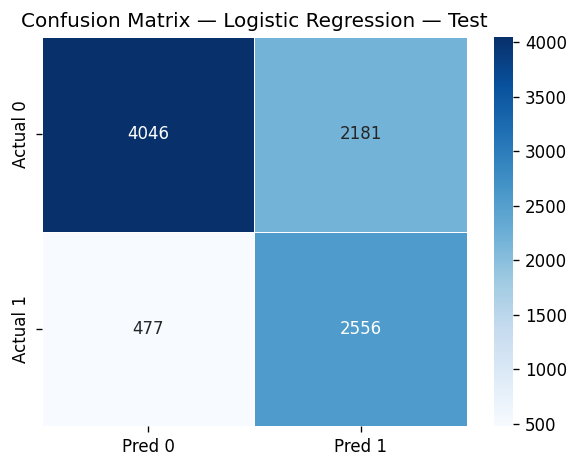


 Train time: 0.27s
   lr_opt_thresh (Val) = 0.3926
   Test F1             = 0.6579
   Input: 24 features, scaled + y_train ✅


In [10]:
# ============================================================
# MODEL 1: Logistic Regression — với scaling (đúng chuẩn)
# Input: X_train_scaled (fit trên train) + y_train
# Threshold Tuning: dùng X_val_scaled → lr_opt_thresh (Anti-Leakage)
# ============================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    solver='lbfgs',
    C=1.0
)

lr_start = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - lr_start

# ── Threshold Tuning trên Validation set (ĐÃ SỬA LỖI ĐỒNG BỘ INDEX) ───────────
lr_val_probs = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_prec_val, lr_rec_val, lr_thresh_vals = precision_recall_curve(y_val, lr_val_probs)

# Cắt đuôi [:-1] để khớp hoàn toàn với số lượng phần tử của mảng lr_thresh_vals
lr_f1_vals   = (2 * lr_prec_val[:-1] * lr_rec_val[:-1] / (lr_prec_val[:-1] + lr_rec_val[:-1] + 1e-8))
lr_best_idx   = np.argmax(lr_f1_vals)
lr_opt_thresh = float(lr_thresh_vals[lr_best_idx])

print(f'🎯 LR — Optimal Threshold (tìm trên Validation set):')
print(f'   lr_opt_thresh = {lr_opt_thresh:.4f}  (vs default 0.5)')
print(f'   F1  (Val)     = {lr_f1_vals[lr_best_idx]:.4f}')
# [SỬA LỖI TRÍCH XUẤT]: Cắt đuôi [:-1] để lấy đúng vị trí tương ứng của Precision và Recall
print(f'   Prec(Val)      = {lr_prec_val[:-1][lr_best_idx]:.4f}')
print(f'   Rec (Val)      = {lr_rec_val[:-1][lr_best_idx]:.4f}')
print()

# Đánh giá trên Test set với threshold tối ưu từ Validation
lr_metrics, lr_probs = evaluate_model(
    lr_model, X_test_scaled, y_test,
    'Logistic Regression — Test', threshold=lr_opt_thresh
)

all_results['Logistic Regression'] = {**lr_metrics, 'Train time (s)': lr_time}
all_probs['Logistic Regression']   = lr_probs

print(f'\n Train time: {lr_time:.2f}s')
print(f'   lr_opt_thresh (Val) = {lr_opt_thresh:.4f}')
print(f'   Test F1             = {lr_metrics["F1-Score"]:.4f}')

# [SỬA LỖI CRASH COEF]: Lấy tên cột từ X_train gốc (vì X_train_scaled có thể là mảng Numpy không có thuộc tính .columns)
feature_names = X_train.columns if hasattr(X_train_scaled, 'columns') == False else X_train_scaled.columns
print(f'   Input: {len(feature_names)} features, scaled + y_train ✅')

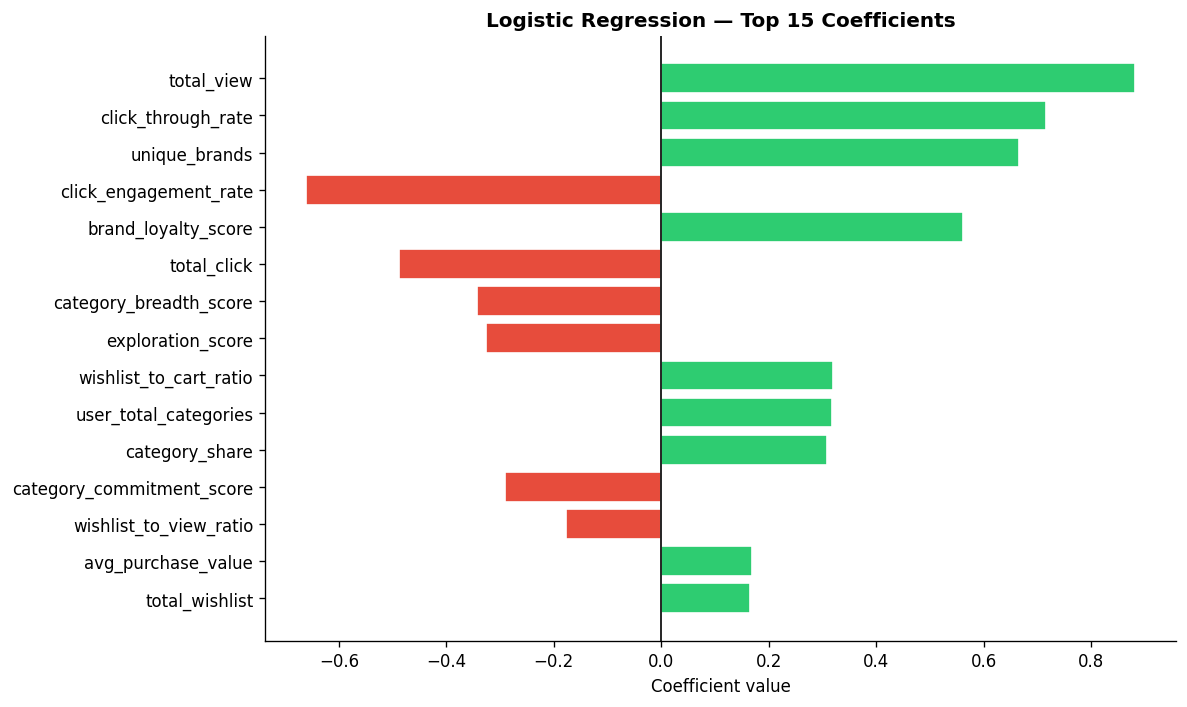


⚠️ Nhận xét:
  LR chỉ học được linear boundary.
  Không bắt được non-linear interactions giữa behavioral features...
  → Cần model phức tạp hơn: XGBoost hoặc LightGBM


In [11]:
# Phân tích coefficients của LR (top features theo magnitude)
coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ECC71' if c > 0 else '#E74C3C' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Logistic Regression — Top 15 Coefficients', fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

print('\n⚠️ Nhận xét:')
print('  LR chỉ học được linear boundary.')
print('  Không bắt được non-linear interactions giữa behavioral features...')
print('  → Cần model phức tạp hơn: XGBoost hoặc LightGBM')

### 🟠 Model 2 — XGBoost (Nâng cao)

**XGBoost (eXtreme Gradient Boosting)** — thuật toán Boosting mạnh mẽ, kết hợp nhiều Decision Tree yếu theo thứ tự tuần tự.
- **Boosting**: mỗi cây mới tập trung học những lỗi mà cây trước chưa sửa đúng → giảm bias
- `scale_pos_weight` xử lý class imbalance (ratio neg/pos)
- Early stopping trên Validation set → chống overfitting, tìm số cây tối ưu
- Không cần scale features (tree-based model)

In [12]:

# ============================================================
# MODEL 2: XGBoost — Gradient Boosting với Early Stopping
# Input: X_train + y_train (unscaled — tree model)
# Early Stopping: eval_set=[(X_val, y_val)] → dừng khi val_logloss không giảm 50 rounds
# ============================================================
import xgboost as xgb

neg_count        = int((y_train == 0).sum())
pos_count        = int((y_train == 1).sum())
scale_pos_weight = neg_count / pos_count
print(f'   scale_pos_weight = {neg_count}/{pos_count} = {scale_pos_weight:.3f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=500,            # Tối đa 500 cây — Early Stopping sẽ dừng sớm hơn
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=50,   # Dừng nếu val_logloss không cải thiện sau 50 rounds
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

print(f'🚀 Training XGBoost (max n_estimators=500, early_stopping_rounds=50)...')
print(f'   Train    : X_train ({X_train.shape[0]:,} dòng × {X_train.shape[1]} features)')
print(f'   Val (ES) : X_val   ({X_val.shape[0]:,} dòng) ← thước đo dừng học')

t0 = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],  # Validation set cho Early Stopping
    verbose=False
)
xgb_time = time.time() - t0

print(f'\n✅ XGBoost hoàn thành — Training time: {xgb_time:.1f}s')
print(f'   Best iteration (Early Stopping): {xgb_model.best_iteration}')
print(f'   (dừng sớm trước 500 rounds — chống overfitting ✅)')
print(f'   Input: X_train (unscaled, {X_train.shape[1]} features) + y_train ✅')
print(f'   Early Stopping trên: X_val / y_val ✅')


   scale_pos_weight = 29053/14154 = 2.053
🚀 Training XGBoost (max n_estimators=500, early_stopping_rounds=50)...
   Train    : X_train (43,207 dòng × 24 features)
   Val (ES) : X_val   (9,261 dòng) ← thước đo dừng học

✅ XGBoost hoàn thành — Training time: 3.8s
   Best iteration (Early Stopping): 215
   (dừng sớm trước 500 rounds — chống overfitting ✅)
   Input: X_train (unscaled, 24 features) + y_train ✅
   Early Stopping trên: X_val / y_val ✅


🎯 XGBoost — Optimal Threshold (tìm trên Validation set):
   xgb_opt_thresh = 0.4772  (vs default 0.5)
   F1  (Val)      = 0.7042
   Prec(Val)      = 0.5758
   Rec (Val)      = 0.9064

  📊 XGBoost — Test Set (threshold = 0.4772)
  Accuracy    : 0.7612
  Precision   : 0.5873
  Recall      : 0.9116
  F1-Score    : 0.7144
  ROC-AUC     : 0.8742

  Classification Report:
               precision    recall  f1-score   support

Không tái mua       0.94      0.69      0.79      6227
      Tái mua       0.59      0.91      0.71      3033

     accuracy                           0.76      9260
    macro avg       0.76      0.80      0.75      9260
 weighted avg       0.83      0.76      0.77      9260



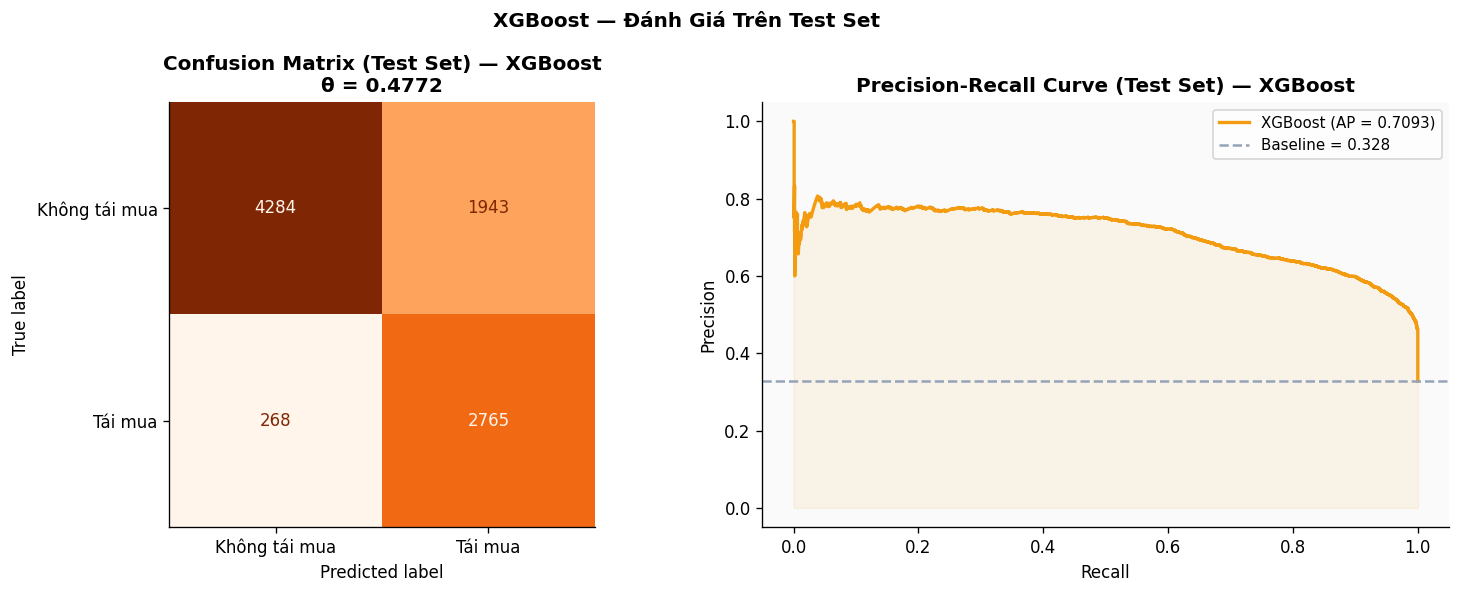

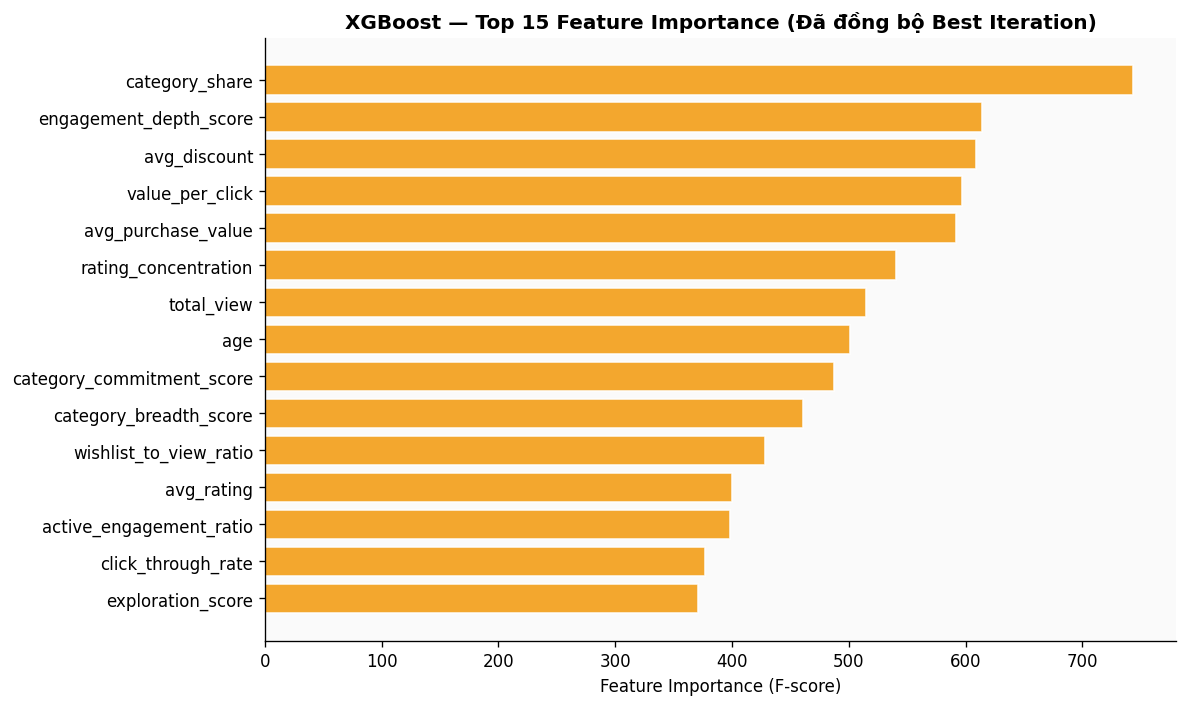


⏱️  Train time: 3.80s
   xgb_opt_thresh (Val) = 0.4772
   Test F1              = 0.7144
   Input: X_train (unscaled, 24 features) + y_train ✅


In [13]:

# ============================================================
# XGBoost: Threshold Tuning trên Validation set + Đánh giá trên Test Set
# ============================================================

# ── Threshold Tuning trên Validation set ──────────────────────────────────────
# ── Threshold Tuning trên Validation set (ĐÃ SỬA LỖI ĐỒNG BỘ INDEX) ───────────
xgb_val_probs = xgb_model.predict_proba(X_val)[:, 1]
xgb_prec_val, xgb_rec_val, xgb_thresh_vals = precision_recall_curve(y_val, xgb_val_probs)

# Tính F1 sạch tương ứng hoàn toàn với số lượng phần tử của xgb_thresh_vals
xgb_f1_vals = (2 * xgb_prec_val[:-1] * xgb_rec_val[:-1]) / (xgb_prec_val[:-1] + xgb_rec_val[:-1] + 1e-8)
xgb_best_idx = np.argmax(xgb_f1_vals)
xgb_opt_thresh = float(xgb_thresh_vals[xgb_best_idx])

print(f'🎯 XGBoost — Optimal Threshold (tìm trên Validation set):')
print(f'   xgb_opt_thresh = {xgb_opt_thresh:.4f}  (vs default 0.5)')
print(f'   F1  (Val)      = {xgb_f1_vals[xgb_best_idx]:.4f}')
# [SỬA LỖI TRÍCH XUẤT]: Lấy đúng vị trí tương ứng trên mảng prec/rec đã cắt đuôi
print(f'   Prec(Val)      = {xgb_prec_val[:-1][xgb_best_idx]:.4f}')
print(f'   Rec (Val)      = {xgb_rec_val[:-1][xgb_best_idx]:.4f}')
print()

# ── Đánh giá trên Test Set với threshold tối ưu ───────────────────────────────
xgb_probs_all = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds     = (xgb_probs_all >= xgb_opt_thresh).astype(int)

acc  = accuracy_score(y_test, xgb_preds)
prec = precision_score(y_test, xgb_preds, zero_division=0)
rec  = recall_score(y_test, xgb_preds, zero_division=0)
f1   = f1_score(y_test, xgb_preds, zero_division=0)
auc  = roc_auc_score(y_test, xgb_probs_all)

print('='*58)
print(f'  📊 XGBoost — Test Set (threshold = {xgb_opt_thresh:.4f})')
print('='*58)
print(f'  Accuracy    : {acc:.4f}')
print(f'  Precision   : {prec:.4f}')
print(f'  Recall      : {rec:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  ROC-AUC     : {auc:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_test, xgb_preds,
                            target_names=['Không tái mua', 'Tái mua']))

# Confusion Matrix + PR Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_xgb = confusion_matrix(y_test, xgb_preds)
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                                display_labels=['Không tái mua', 'Tái mua'])
disp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title(f'Confusion Matrix (Test Set) — XGBoost\nθ = {xgb_opt_thresh:.4f}',
                  fontweight='bold')

pr_prec, pr_rec, _ = precision_recall_curve(y_test, xgb_probs_all)
ap       = average_precision_score(y_test, xgb_probs_all)
baseline = float(y_test.mean())
axes[1].plot(pr_rec, pr_prec, color='#F39C12', lw=2, label=f'XGBoost (AP = {ap:.4f})')
axes[1].axhline(baseline, linestyle='--', color='#94A3B8', label=f'Baseline = {baseline:.3f}')
axes[1].fill_between(pr_rec, pr_prec, alpha=0.08, color='#F39C12')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Test Set) — XGBoost', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].set_facecolor('#FAFAFA')
plt.suptitle('XGBoost — Đánh Giá Trên Test Set', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Feature Importance (ĐÃ SỬA LỖI ĐỌC THUỘC TÍNH MÔ HÌNH CÂY TỐI ƯU) ─────────
# Ép mô hình lấy điểm trọng số dựa trên số lượng cây thực tế tốt nhất (best_iteration)
importance_scores = xgb_model.get_booster().get_score(importance_type='weight')
# Khớp tên cột với điểm số (vì get_score có thể bỏ qua các biến có tầm quan trọng = 0)
xgb_importance_df = pd.DataFrame({
    'Feature': list(importance_scores.keys()),
    'Importance': list(importance_scores.values())
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(xgb_importance_df['Feature'][::-1], xgb_importance_df['Importance'][::-1],
        color='#F39C12', edgecolor='white', alpha=0.88)
ax.set_title('XGBoost — Top 15 Feature Importance (Đã đồng bộ Best Iteration)', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Importance (F-score)')
ax.set_facecolor('#FAFAFA')
plt.tight_layout(); plt.show()

all_results['XGBoost'] = {
    'Accuracy': acc, 'Precision': prec, 'Recall': rec,
    'F1-Score': f1, 'ROC-AUC': auc, 'Train time (s)': xgb_time,
}
all_probs['XGBoost'] = xgb_probs_all

print(f'\n⏱️  Train time: {xgb_time:.2f}s')
print(f'   xgb_opt_thresh (Val) = {xgb_opt_thresh:.4f}')
print(f'   Test F1              = {f1:.4f}')
print(f'   Input: X_train (unscaled, {X_train.shape[1]} features) + y_train ✅')


### 🟢 Model 3 — LightGBM (Best Model)

**LightGBM (Light Gradient Boosting Machine)** — thuật toán tốt nhất trong pipeline.
- **Leaf-wise** tree growth (thay vì level-wise như XGBoost) → converge nhanh hơn
- Xử lý dữ liệu lớn nhanh hơn 3-10x so với XGBoost
- `class_weight='balanced'` tự động điều chỉnh class imbalance
- **Optimal Threshold:** Thay vì dùng 0.5 mặc định, tìm ngưỡng tối ưu trên Precision-Recall curve (Validation set) để maximize F1


In [14]:

# ============================================================
# MODEL 3: LightGBM — với Early Stopping trên Validation set
# Input: X_train + y_train (unscaled — tree model)
# Early Stopping: eval_set=[(X_val, y_val)], stopping_rounds=50
# ============================================================
lgbm_model = LGBMClassifier(
    n_estimators=500,           # Tối đa 500 cây — Early Stopping dừng sớm hơn
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

print(f'🚀 Training LightGBM (max n_estimators=500, early_stopping_rounds=50)...')
print(f'   Train    : X_train ({X_train.shape[0]:,} dòng × {X_train.shape[1]} features)')
print(f'   Val (ES) : X_val   ({X_val.shape[0]:,} dòng) ← thước đo dừng học')

t0 = time.time()
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],   # Validation set cho Early Stopping
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=-1),  # Tắt log verbose
    ]
)
lgbm_time = time.time() - t0

print(f'\n✅ LightGBM hoàn thành — Training time: {lgbm_time:.1f}s')
print(f'   Best iteration (Early Stopping): {lgbm_model.best_iteration_}')
print(f'   (dừng sớm trước 500 rounds — chống overfitting ✅)')
print(f'   Input: X_train (unscaled, {X_train.shape[1]} features) + y_train ✅')
print(f'   Early Stopping trên: X_val / y_val ✅')


🚀 Training LightGBM (max n_estimators=500, early_stopping_rounds=50)...
   Train    : X_train (43,207 dòng × 24 features)
   Val (ES) : X_val   (9,261 dòng) ← thước đo dừng học

✅ LightGBM hoàn thành — Training time: 1.6s
   Best iteration (Early Stopping): 209
   (dừng sớm trước 500 rounds — chống overfitting ✅)
   Input: X_train (unscaled, 24 features) + y_train ✅
   Early Stopping trên: X_val / y_val ✅



🎯 OPTIMAL THRESHOLD LightGBM (maximize F1 trên Validation set):
   lgbm_opt_thresh = 0.4707  (vs default 0.5)
   F1  (Val)       = 0.7063
   Precision (Val) = 0.5742
   Recall    (Val) = 0.9173
   ✅ Dùng X_val để tìm threshold — không rò rỉ thông tin từ test set


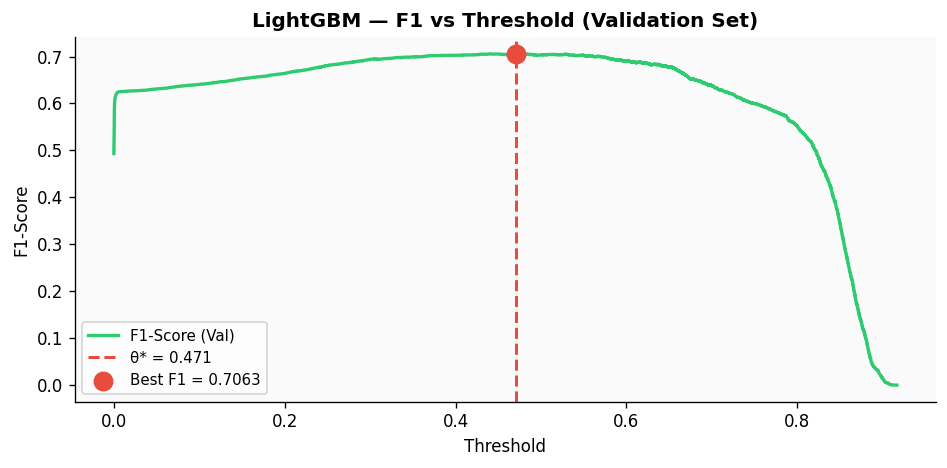


✅ Toàn bộ tài nguyên đã được lưu thành công vào thư mục C:\Users\ADMIN\MOCK PROJECT VTI\mini_project_ml\models:
   ├─ Mô hình LightGBM tốt nhất : best_model.pkl
   └─ Ngưỡng cắt tối ưu         : optimal_threshold.pkl


In [15]:
# ============================================================
# LightGBM: Threshold tối ưu — dùng Validation set (ĐA SỬA LỖI ĐỒNG BỘ INDEX)
# ============================================================
lgbm_val_probs = lgbm_model.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, lgbm_val_probs)

# Tính F1 sạch tương ứng hoàn toàn với số lượng phần tử của mảng thresholds
f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
lgbm_opt_thresh = float(thresholds[best_idx])

print(f'\n🎯 OPTIMAL THRESHOLD LightGBM (maximize F1 trên Validation set):')
print(f'   lgbm_opt_thresh = {lgbm_opt_thresh:.4f}  (vs default 0.5)')
print(f'   F1  (Val)       = {f1_scores[best_idx]:.4f}')
# [SỬA LỖI TRÍCH XUẤT]: Cắt đuôi [:-1] để lấy đúng vị trí tương ứng của Precision và Recall
print(f'   Precision (Val) = {precisions[:-1][best_idx]:.4f}')
print(f'   Recall    (Val) = {recalls[:-1][best_idx]:.4f}')
print(f'   ✅ Dùng X_val để tìm threshold — không rò rỉ thông tin từ test set')

# Plot F1 vs Threshold (trên Validation set)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores, color='#2ECC71', lw=2, label='F1-Score (Val)')
ax.axvline(lgbm_opt_thresh, color='#E74C3C', linestyle='--', lw=1.8,
           label=f'θ* = {lgbm_opt_thresh:.3f}')
ax.scatter(lgbm_opt_thresh, f1_scores[best_idx],
           color='#E74C3C', s=120, zorder=5, label=f'Best F1 = {f1_scores[best_idx]:.4f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1-Score')
ax.set_title('LightGBM — F1 vs Threshold (Validation Set)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.show()

# [SỬA LỖI LƯU TRỮ]: Đóng gói lưu cả file MÔ HÌNH lẫn file NGƯỠNG TỐI ƯU vào thư mục
import joblib
joblib.dump(lgbm_model, MODELS_DIR / 'best_model.pkl') # Lưu bộ não mô hình LightGBM
joblib.dump(lgbm_opt_thresh, MODELS_DIR / 'optimal_threshold.pkl') # Lưu ngưỡng tối ưu

print(f'\n✅ Toàn bộ tài nguyên đã được lưu thành công vào thư mục {MODELS_DIR}:')
print(f'   ├─ Mô hình LightGBM tốt nhất : best_model.pkl')
print(f'   └─ Ngưỡng cắt tối ưu         : optimal_threshold.pkl')


  📊 LightGBM — Test Set (threshold = 0.4707)
  Accuracy    : 0.7581
  Precision   : 0.5828
  Recall      : 0.9205
  F1-Score    : 0.7137
  ROC-AUC     : 0.8749

  Classification Report:
               precision    recall  f1-score   support

Không tái mua       0.95      0.68      0.79      6227
      Tái mua       0.58      0.92      0.71      3033

     accuracy                           0.76      9260
    macro avg       0.76      0.80      0.75      9260
 weighted avg       0.83      0.76      0.77      9260



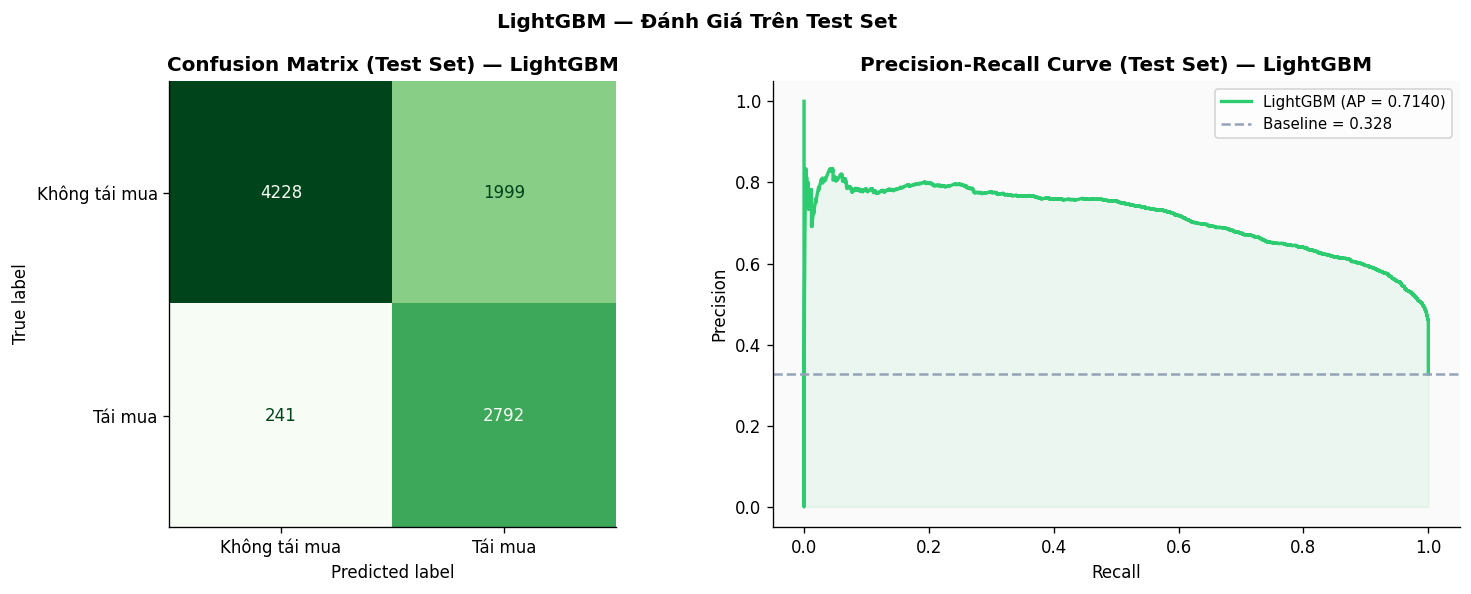


⏱️  Train time: 1.63s
   Test F1 = 0.7137
   Input: X_train (unscaled, 24 features) + y_train ✅


In [16]:
# ============================================================
# LightGBM: Đánh giá trên Test Set (threshold = optimal_threshold)
# ============================================================
lgbm_probs_all = lgbm_model.predict_proba(X_test)[:, 1]
lgbm_preds     = (lgbm_probs_all >= lgbm_opt_thresh).astype(int)

acc  = accuracy_score(y_test, lgbm_preds)
prec = precision_score(y_test, lgbm_preds, zero_division=0)
rec  = recall_score(y_test, lgbm_preds, zero_division=0)
f1   = f1_score(y_test, lgbm_preds, zero_division=0)
auc  = roc_auc_score(y_test, lgbm_probs_all)

print('='*60)
print(f'  📊 LightGBM — Test Set (threshold = {lgbm_opt_thresh:.4f})')
print('='*60)
print(f'  Accuracy    : {acc:.4f}')
print(f'  Precision   : {prec:.4f}')
print(f'  Recall      : {rec:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  ROC-AUC     : {auc:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_test, lgbm_preds,
                            target_names=['Không tái mua', 'Tái mua']))

# Confusion Matrix + PR Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_lgbm = confusion_matrix(y_test, lgbm_preds)
disp    = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm,
                                 display_labels=['Không tái mua', 'Tái mua'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix (Test Set) — LightGBM', fontweight='bold')

pr_prec, pr_rec, _ = precision_recall_curve(y_test, lgbm_probs_all)
ap       = average_precision_score(y_test, lgbm_probs_all)
baseline = float(y_test.mean())
axes[1].plot(pr_rec, pr_prec, color='#2ECC71', lw=2, label=f'LightGBM (AP = {ap:.4f})')
axes[1].axhline(baseline, linestyle='--', color='#94A3B8', label=f'Baseline = {baseline:.3f}')
axes[1].fill_between(pr_rec, pr_prec, alpha=0.08, color='#2ECC71')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Test Set) — LightGBM', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].set_facecolor('#FAFAFA')
plt.suptitle('LightGBM — Đánh Giá Trên Test Set', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

all_results['LightGBM'] = {
    'Accuracy': acc, 'Precision': prec, 'Recall': rec,
    'F1-Score': f1, 'ROC-AUC': auc, 'Train time (s)': lgbm_time,
}
all_probs['LightGBM'] = lgbm_probs_all

print(f'\n⏱️  Train time: {lgbm_time:.2f}s')
print(f'   Test F1 = {f1:.4f}')
print(f'   Input: X_train (unscaled, {X_train.shape[1]} features) + y_train ✅')



---
## 📌 Bước 10 / 15 — Đánh Giá Baseline (Feature Importance)

> **Mục tiêu:** Sau khi 3 models đã huấn luyện xong (Bước 9), bước này đánh giá tầm quan trọng của từng feature thông qua Feature Importance từ LightGBM và XGBoost.  
> Kết quả được dùng để quyết định giữ lại feature nào trong Bước 11 (Feature Reduction).



✅ Feature importance đã lưu: C:\Users\ADMIN\MOCK PROJECT VTI\mini_project_ml\models\feature_importance.csv


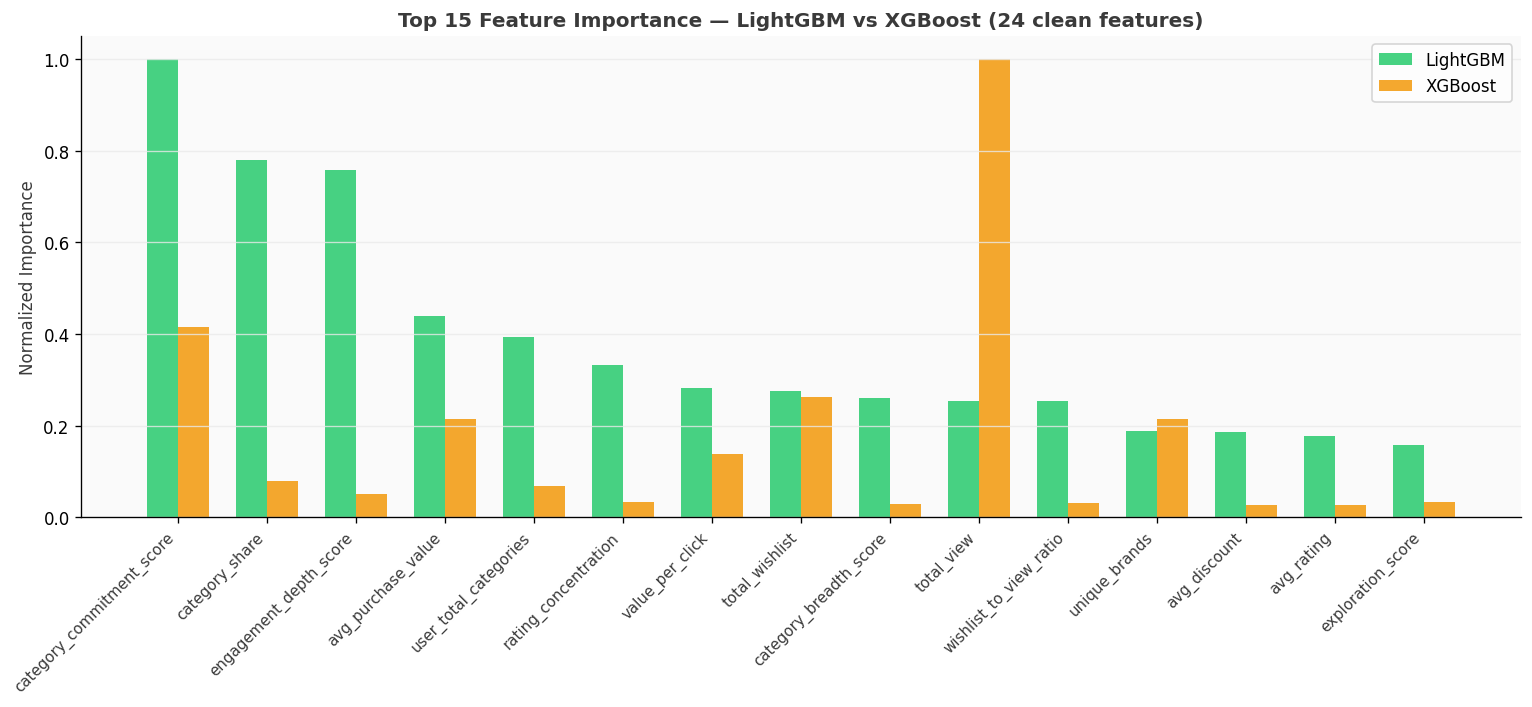


🔍 Top 10 features (clean — không có total_interactions / avg_price):
   category_commitment_score           LGBM:   1546 | XGB: 0.1424
   category_share                      LGBM:   1205 | XGB: 0.0272
   engagement_depth_score              LGBM:   1170 | XGB: 0.0176
   avg_purchase_value                  LGBM:    678 | XGB: 0.0738
   user_total_categories               LGBM:    608 | XGB: 0.0233
   rating_concentration                LGBM:    515 | XGB: 0.0113
   value_per_click                     LGBM:    435 | XGB: 0.0474
   total_wishlist                      LGBM:    427 | XGB: 0.0898
   category_breadth_score              LGBM:    402 | XGB: 0.0100
   total_view                          LGBM:    394 | XGB: 0.3419


In [17]:
# ============================================================
# Feature Importance: LightGBM vs XGBoost — 24 clean features
# (total_interactions đã bị loại; avg_price, view_to_click_ratio,
#  cart_to_click_ratio, discount_sensitivity, price_to_value_ratio đã loại)
# ============================================================
features = list(X_train.columns)

lgbm_imp = pd.DataFrame({
    'Feature'           : features,
    'LightGBM_Importance': lgbm_model.feature_importances_,
}).sort_values('LightGBM_Importance', ascending=False)

xgb_imp = pd.DataFrame({
    'Feature'          : features,
    'XGBoost_Importance': xgb_model.feature_importances_,
})

feature_importance_df = lgbm_imp.merge(xgb_imp, on='Feature').sort_values(
    'LightGBM_Importance', ascending=False
)
feature_importance_df['Avg_Importance'] = (
    feature_importance_df['LightGBM_Importance'] +
    feature_importance_df['XGBoost_Importance']
) / 2

# Save to CSV
fi_path = MODELS_DIR / 'feature_importance.csv'
feature_importance_df.to_csv(fi_path, index=False)
print(f'✅ Feature importance đã lưu: {fi_path}')

# ── Plot — VI style comparison chart ─────────────────────────────────────────
# LightGBM: #2ECC71 | XGBoost: #F39C12 — model identity colors (nhất quán với PALETTE_3)
top_n   = 15
top_df  = feature_importance_df.head(top_n)
x_pos   = np.arange(len(top_df))
bar_w   = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
lgbm_norm = top_df['LightGBM_Importance'] / top_df['LightGBM_Importance'].max()
xgb_norm  = top_df['XGBoost_Importance']  / top_df['XGBoost_Importance'].max()

ax.bar(x_pos - bar_w/2, lgbm_norm, bar_w, label='LightGBM', color='#2ECC71', alpha=0.88)
ax.bar(x_pos + bar_w/2, xgb_norm,  bar_w, label='XGBoost',  color='#F39C12', alpha=0.88)

ax.set_xticks(x_pos)
ax.set_xticklabels(top_df['Feature'], rotation=45, ha='right', fontsize=9, color='#3A3A3A')
ax.set_title(f'Top {top_n} Feature Importance — LightGBM vs XGBoost (24 clean features)',
             fontsize=12, fontweight='bold', color='#3A3A3A')
ax.set_ylabel('Normalized Importance', color='#3A3A3A')
ax.legend(fontsize=10)
ax.set_facecolor('#FAFAFA')
ax.grid(axis='y', color='#EAEAEA', alpha=0.8)
plt.tight_layout()
plt.show()

print(f'\n🔍 Top 10 features (clean — không có total_interactions / avg_price):')
for _, row in feature_importance_df.head(10).iterrows():
    print(f'   {row["Feature"]:<35} LGBM: {row["LightGBM_Importance"]:>6.0f} | '
          f'XGB: {row["XGBoost_Importance"]:>6.4f}')



---
## 📌 Bước 11 / 15 — Feature Reduction & Lưu Pipeline

> **Mục tiêu:** Dựa trên Feature Importance từ Bước 10, xác nhận danh sách features cuối cùng.  
> Toàn bộ models, thresholds tối ưu, dữ liệu test/val và predictions được lưu lại để NB4 đánh giá.



In [18]:

# ============================================================
# Lưu tất cả models, 3 optimal thresholds và dữ liệu val/test
# ============================================================

# Models
joblib.dump(lgbm_model, MODELS_DIR / 'best_model.pkl')
joblib.dump(xgb_model,  MODELS_DIR / 'xgb_model.pkl')
joblib.dump(lr_model,   MODELS_DIR / 'lr_model.pkl')

# 3 Optimal Thresholds — mỗi model có ngưỡng tối ưu riêng (tìm trên Val)
joblib.dump(lr_opt_thresh,    MODELS_DIR / 'lr_optimal_threshold.pkl')
joblib.dump(xgb_opt_thresh,   MODELS_DIR / 'xgb_optimal_threshold.pkl')
joblib.dump(lgbm_opt_thresh,  MODELS_DIR / 'optimal_threshold.pkl')   # backward compat alias

# Test data + Val data (NB4 dùng Test; Val lưu kèm để debug nếu cần)
joblib.dump({
    'X_test'   : X_test,         # 24 features (unscaled) — XGBoost / LightGBM
    'X_test_lr': X_test_scaled,  # 24 features (scaled)   — Logistic Regression
    'y_test'   : y_test,
    'X_val'    : X_val,          # Val unscaled (lưu kèm để debug)
    'X_val_lr' : X_val_scaled,   # Val scaled   (lưu kèm để debug)
    'y_val'    : y_val,
}, MODELS_DIR / 'test_data.pkl')

print('✅ Models đã lưu:')
print(f'   models/best_model.pkl              ← LightGBM (best model)')
print(f'   models/xgb_model.pkl               ← XGBoost')
print(f'   models/lr_model.pkl                ← Logistic Regression')
print(f'   models/preprocessor.pkl            ← StandardScaler + encoders')
print(f'   models/feature_importance.csv')
print()
print('✅ Optimal Thresholds đã lưu (tuned trên Validation set):')
print(f'   models/lr_optimal_threshold.pkl    ← {lr_opt_thresh:.4f}   (LR)')
print(f'   models/xgb_optimal_threshold.pkl   ← {xgb_opt_thresh:.4f}   (XGBoost)')
print(f'   models/optimal_threshold.pkl       ← {lgbm_opt_thresh:.4f}   (LightGBM)')
print()
print('✅ Data đã lưu:')
print(f'   models/test_data.pkl               ← X_test, X_val, y_test, y_val')
print()
print(f'   Train : {X_train.shape[0]:,} dòng × {X_train.shape[1]} features  (70%)')
print(f'   Val   : {X_val.shape[0]:,}  dòng × {X_val.shape[1]} features  (15%)')
print(f'   Test  : {X_test.shape[0]:,}  dòng × {X_test.shape[1]} features  (15%)')
print(f'\n   ✅ Pipeline: 70% Train / 15% Val / 15% Test — chuẩn công nghiệp')
print(f'   ✅ Features: {len(ALL_FEATURE_COLS)} raw + {len(DERIVED_COLS)} derived = {len(ALL_FEATURE_COLS)+len(DERIVED_COLS)} clean features')


✅ Models đã lưu:
   models/best_model.pkl              ← LightGBM (best model)
   models/xgb_model.pkl               ← XGBoost
   models/lr_model.pkl                ← Logistic Regression
   models/preprocessor.pkl            ← StandardScaler + encoders
   models/feature_importance.csv

✅ Optimal Thresholds đã lưu (tuned trên Validation set):
   models/lr_optimal_threshold.pkl    ← 0.3926   (LR)
   models/xgb_optimal_threshold.pkl   ← 0.4772   (XGBoost)
   models/optimal_threshold.pkl       ← 0.4707   (LightGBM)

✅ Data đã lưu:
   models/test_data.pkl               ← X_test, X_val, y_test, y_val

   Train : 43,207 dòng × 24 features  (70%)
   Val   : 9,261  dòng × 24 features  (15%)
   Test  : 9,260  dòng × 24 features  (15%)

   ✅ Pipeline: 70% Train / 15% Val / 15% Test — chuẩn công nghiệp
   ✅ Features: 13 raw + 11 derived = 24 clean features


In [19]:

# ============================================================
# Export Prediction CSVs — Test set (15%) cho Backend / UI
#
# 3 file xuất ra data/:
#   predictions_lr.csv    ← Logistic Regression
#   predictions_xgb.csv   ← XGBoost
#   predictions_lgbm.csv  ← LightGBM
#
# Cấu trúc mỗi file (~9,259 dòng):
#   user_id, product_category    ← keys định danh
#   [13 raw features]            ← age, total_view, cart_rate, avg_rating...
#   [11 derived features]        ← wishlist_to_view_ratio, brand_loyalty_score...
#   repurchase                   ← nhãn thực tế (0/1)
#   repurchase_prob              ← xác suất tái mua (0.0–1.0)
#   repurchase_pred              ← dự đoán nhị phân (0/1) dùng theta*
#   threshold_used               ← giá trị theta* từ Validation set
#   model                        ← tên model
#   split                        ← 'test'
# ============================================================

# Meta columns (user_id + product_category) — lấy theo index test
meta_test = df.loc[X_test.index, ['user_id', 'product_category']].reset_index(drop=True)

# Full feature matrix + actual label (24 features + repurchase) — test rows
feat_test = df_featured.loc[X_test.index].reset_index(drop=True)

# Model configs: (model, X_input_scaled_or_not, threshold, label, filename)
export_cfgs = [
    (lr_model,   X_test_scaled, lr_opt_thresh,   'LR',       'predictions_lr.csv'),
    (xgb_model,  X_test,        xgb_opt_thresh,  'XGBoost',  'predictions_xgb.csv'),
    (lgbm_model, X_test,        lgbm_opt_thresh, 'LightGBM', 'predictions_lgbm.csv'),
]

print('Export Prediction CSVs — Test set (15%)')
print('=' * 68)

for model, X_input, thresh, mname, fname in export_cfgs:
    # Dự đoán xác suất và nhãn nhị phân
    probs = model.predict_proba(X_input)[:, 1]
    preds = (probs >= thresh).astype(int)

    # Cột dự đoán
    pred_info = pd.DataFrame({
        'repurchase_prob' : probs.round(6),
        'repurchase_pred' : preds,
        'threshold_used'  : round(thresh, 4),
        'model'           : mname,
        'split'           : 'test',
    })

    # Ghép: keys | 24 features + actual label | prediction info
    out_df = pd.concat([meta_test, feat_test, pred_info], axis=1)

    # Lưu CSV
    out_df.to_csv(DATA_DIR / fname, index=False, encoding='utf-8-sig')

    # Thống kê nhanh
    actual = feat_test['repurchase']
    tp = int(((actual == 1) & (pred_info['repurchase_pred'] == 1)).sum())
    fp = int(((actual == 0) & (pred_info['repurchase_pred'] == 1)).sum())
    fn = int(((actual == 1) & (pred_info['repurchase_pred'] == 0)).sum())
    tn = int(((actual == 0) & (pred_info['repurchase_pred'] == 0)).sum())

    print(f'\n  [{mname}]  →  data/{fname}')
    print(f'  Rows: {len(out_df):,}  |  Cols: {len(out_df.columns)}  '
          f'(2 keys + 24 features + 1 actual + 5 pred)')
    print(f'  theta* = {thresh:.4f}  |  Pred=1: {preds.sum():,}  Pred=0: {(preds==0).sum():,}')
    print(f'  TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')


Export Prediction CSVs — Test set (15%)

  [LR]  →  data/predictions_lr.csv
  Rows: 9,260  |  Cols: 32  (2 keys + 24 features + 1 actual + 5 pred)
  theta* = 0.3926  |  Pred=1: 4,737  Pred=0: 4,523
  TP=2,556  FP=2,181  FN=477  TN=4,046

  [XGBoost]  →  data/predictions_xgb.csv
  Rows: 9,260  |  Cols: 32  (2 keys + 24 features + 1 actual + 5 pred)
  theta* = 0.4772  |  Pred=1: 4,708  Pred=0: 4,552
  TP=2,765  FP=1,943  FN=268  TN=4,284

  [LightGBM]  →  data/predictions_lgbm.csv
  Rows: 9,260  |  Cols: 32  (2 keys + 24 features + 1 actual + 5 pred)
  theta* = 0.4707  |  Pred=1: 4,791  Pred=0: 4,469
  TP=2,792  FP=1,999  FN=241  TN=4,228
